# Load Parameters

In [1]:
import json 
import os

path = "./params/folder_results_mnist_results_20260613_150008/"

files = os.listdir(path=path)

print(files)

json_file = None

with open(os.path.join(path, "model_results.json"), 'r', encoding='utf-8') as f:
    json_file = json.load(f)

['softmax-10-bias.npz', 'neural-9-weights.npz', 'conv2d-1-bias.npz', 'pool-2-bias.npz', 'conv2d-3-weights.npz', 'conv2d-3-bias.npz', 'model_results.json', 'pool-6-bias.npz', 'conv2d-5-weights.npz', 'neural-8-bias.npz', 'pool-6-weights.npz', 'pool-2-weights.npz', 'pool-4-bias.npz', 'conv2d-1-weights.npz', 'pool-4-weights.npz', 'flatten-7-weights.npz', 'neural-8-weights.npz', 'neural-9-bias.npz', 'softmax-10-weights.npz', 'conv2d-5-bias.npz', 'flatten-7-bias.npz']


In [2]:
layer_map = ['neural', 'conv2d', 'pool', 'flatten']

model_conf = json_file['configuration']
len(model_conf)

10

In [3]:
import os
import numpy as np


def load_npz_array(file_path: str, key: str, dtype=np.float32):
    data = np.load(file_path, allow_pickle=True)
    arr = data[key]

    if isinstance(arr, np.ndarray) and arr.dtype == object:
        if arr.shape == ():
            arr = arr.item()
        else:
            arr = np.array(arr.tolist())

    arr = np.asarray(arr, dtype=dtype)

    return arr


weights_bias = {}

for i in model_conf:
    has_forward = i["forward"]
    model_name = i["name"]

    if has_forward:
        weights_path = os.path.join(path, i["wparam"])
        bias_path = os.path.join(path, i["bparam"])

        w_matrix = load_npz_array(weights_path, "weights")
        b_matrix = load_npz_array(bias_path, "bias")

        print(
            w_matrix.shape,
            w_matrix.dtype,
            b_matrix.shape,
            b_matrix.dtype,
            model_name
        )

        weights_bias[model_name] = {
            "w": w_matrix,
            "b": b_matrix
        }

    else:
        weights_bias[model_name] = None

(8, 1, 3, 3) float32 (8,) float32 conv2d-1
(1,) float32 (1,) float32 pool-2
(16, 8, 3, 3) float32 (16,) float32 conv2d-3
(1,) float32 (1,) float32 pool-4
(32, 16, 3, 3) float32 (32,) float32 conv2d-5
(1,) float32 (1,) float32 pool-6
(1,) float32 (1,) float32 flatten-7
(32, 16) float32 (1, 16) float32 neural-8
(16, 10) float32 (1, 10) float32 neural-9
(1,) float32 (1,) float32 softmax-10


# Model

In [4]:
import numpy as np


class NeuralNetwork:
    def __init__(self, W: np.ndarray, b: np.ndarray):
        self.W = W
        self.b = b

    def forward(self, x: np.ndarray) -> np.ndarray:
        z = x @ self.W + self.b
        return np.maximum(0.0, z)


class Convolution2D:
    def __init__(
        self,
        in_channel: int,
        out_channel: int,
        k_size: int,
        stride: int,
        W: np.ndarray,
        b: np.ndarray,
    ):
        self.W = W
        self.b = b
        self.in_channel = in_channel
        self.out_channel = out_channel
        self.k_size = k_size
        self.stride = stride

    def im2col(self, x: np.ndarray, k_size: int, stride: int = 1) -> np.ndarray:
        C, H, W = x.shape
        H_out = (H - k_size) // stride + 1
        W_out = (W - k_size) // stride + 1

        shape = (C, H_out, W_out, k_size, k_size)
        strides = (
            x.strides[0],
            x.strides[1] * stride,
            x.strides[2] * stride,
            x.strides[1],
            x.strides[2],
        )
        patches = np.lib.stride_tricks.as_strided(x, shape=shape, strides=strides)

        col = patches.transpose(0, 3, 4, 1, 2).reshape(C * k_size * k_size, -1)
        return col

    def forward(self, x: np.ndarray) -> np.ndarray:
        C, H, W_img = x.shape

        if C != self.in_channel:
            raise ValueError(
                f"Channel input {C} tidak sesuai dengan in_channel={self.in_channel}."
            )
        if H < self.k_size or W_img < self.k_size:
            raise ValueError(
                f"Kernel size {self.k_size} lebih besar dari "
                f"spatial input ({H}x{W_img})."
            )

        H_out = (H - self.k_size) // self.stride + 1
        W_out = (W_img - self.k_size) // self.stride + 1

        col   = self.im2col(x, self.k_size, self.stride)
        W_col = self.W.reshape(self.out_channel, -1)

        z = W_col @ col
        z += self.b[:, np.newaxis]
        z = z.reshape(self.out_channel, H_out, W_out)

        return np.maximum(0.0, z)


class MaxPooling:
    def __init__(self):
        pass

    def forward(self, x: np.ndarray) -> np.ndarray:
        if x.ndim != 3:
            raise ValueError(
                f"Input harus 3-D (C, H, W), dapat {x.shape}."
            )
        return self._local_forward(x)

    def _local_forward(self, x: np.ndarray) -> np.ndarray:
        C, H, W = x.shape
        k, s = 2, 2

        if H < k or W < k:
            raise ValueError(
                f"Kernel ({k}x{k}) lebih besar dari spatial input ({H}x{W})."
            )

        H_out = (H - k) // s + 1
        W_out = (W - k) // s + 1

        shape = (C, H_out, W_out, k, k)
        strides = (
            x.strides[0],
            x.strides[1] * s,
            x.strides[2] * s,
            x.strides[1],
            x.strides[2],
        )
        windows = np.lib.stride_tricks.as_strided(x, shape=shape, strides=strides)

        out = windows.reshape(C, H_out, W_out, k * k).max(axis=-1)
        return out


class FlattenLayer:
    def __init__(self):
        pass

    def forward(self, x: np.ndarray) -> np.ndarray:
        return x.flatten()


class SoftmaxLayer:
    def __init__(self):
        pass

    def forward(self, z: np.ndarray) -> np.ndarray:
        z_shifted = z - np.max(z)
        exp_z = np.exp(z_shifted)
        return exp_z / np.sum(exp_z)

# Model Load and Defenitions

In [5]:
conv1_weights = weights_bias['conv2d-1']['w']
conv1_bias = weights_bias['conv2d-1']['b']
conv1 = Convolution2D(1, 8, 3, 1, conv1_weights, conv1_bias)

conv2_weights = weights_bias['conv2d-3']['w']
conv2_bias = weights_bias['conv2d-3']['b']
conv2 = Convolution2D(8, 16, 3, 1, conv2_weights, conv2_bias)

conv3_weights = weights_bias['conv2d-5']['w']
conv3_bias = weights_bias['conv2d-5']['b']
conv3 = Convolution2D(16, 32, 3, 1, conv3_weights, conv3_bias)

In [6]:
neural1_weights = weights_bias["neural-8"]["w"]
neural1_bias = weights_bias["neural-8"]["b"]
neural1 = NeuralNetwork(neural1_weights, neural1_bias)

neural2_weights = weights_bias["neural-9"]["w"]
neural2_bias = weights_bias["neural-9"]["b"]
neural2 = NeuralNetwork(neural2_weights, neural2_bias)

In [7]:
pool = MaxPooling()

In [8]:
flatten = FlattenLayer()

In [9]:
softmax = SoftmaxLayer()

# Data

In [10]:
import numpy as np
from pathlib import Path

def load_mem_image(file_path, shape=(28, 28), normalize=True):
    """
    Membaca file .mem berisi 1 pixel hex per baris.
    Output default:
        shape: 28x28
        range: 0.0 - 1.0
    """

    file_path = Path(file_path)

    values = []

    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()

            # skip baris kosong
            if not line:
                continue

            # kalau ada comment
            line = line.split("//")[0].strip()
            line = line.split("#")[0].strip()

            if not line:
                continue

            # parse hex, contoh: "00", "7F", "FF"
            values.append(int(line, 16))

    arr = np.array(values, dtype=np.uint8)

    expected_size = np.prod(shape)
    if arr.size != expected_size:
        raise ValueError(
            f"Jumlah pixel salah. Dapat {arr.size}, expected {expected_size} untuk shape {shape}"
        )

    arr = arr.reshape(shape)

    if normalize:
        arr = arr.astype(np.float32) / 255.0

    return arr

In [11]:
img = load_mem_image("./image-hex-gen/mnist_img_0/img_0.mem", normalize=False)

print(img.shape)
print(img.min(), img.max())

(28, 28)
0 255


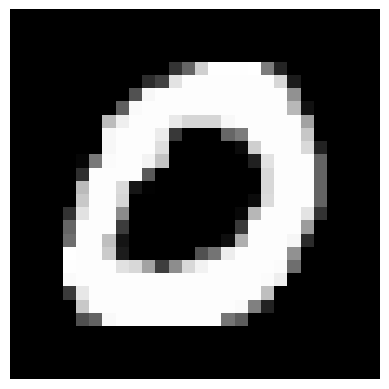

In [12]:
import matplotlib.pyplot as plt

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

# Check

In [13]:
import numpy as np
import pandas as pd


def sign_extend(arr, bit_width):
    """
    Untuk mengubah unsigned two's complement menjadi signed integer.
    Contoh kalau ACT_SIZE = 24, maka bit_width = 24.
    """
    arr = arr.astype(np.int64)

    if bit_width is None:
        return arr

    sign_bit = 1 << (bit_width - 1)
    full_range = 1 << bit_width

    return np.where(arr >= sign_bit, arr - full_range, arr)


def python_float_to_fixed(arr, frac_bits=14, mode="round"):
    """
    Convert float Python ke fixed-point integer.
    """
    scale = 1 << frac_bits
    scaled = arr * scale

    if mode == "round":
        return np.round(scaled).astype(np.int64)

    elif mode == "trunc":
        return np.trunc(scaled).astype(np.int64)

    elif mode == "floor":
        return np.floor(scaled).astype(np.int64)

    else:
        raise ValueError("mode harus 'round', 'trunc', atau 'floor'")


def compare_numpy_vs_verilog(
    python_res,
    verilog_res,
    row_count,
    channel_count,
    prefix="ch",
    frac_bits=14,
    bit_width=24,
    verilog_is_fixed=True,
    quant_mode="round"
):
    """
    Membandingkan hasil NumPy Python vs hasil Verilog/Icarus.

    python_res:
        shape (row_count, channel_count)
        biasanya float

    verilog_res:
        shape (row_count, channel_count)
        biasanya integer fixed-point dari Verilog

    Output dataframe:
        ch0_verilog, ch0_python, ..., ch7_verilog, ch7_python, float_diff, bit_diff
    """

    python_res = np.asarray(python_res, dtype=np.float64)
    verilog_res = np.asarray(verilog_res)

    expected_shape = (row_count, channel_count)

    if python_res.shape != expected_shape:
        raise ValueError(
            f"Shape python_res salah. Dapat {python_res.shape}, expected {expected_shape}"
        )

    if verilog_res.shape != expected_shape:
        raise ValueError(
            f"Shape verilog_res salah. Dapat {verilog_res.shape}, expected {expected_shape}"
        )

    if verilog_is_fixed:
        verilog_fixed = verilog_res.astype(np.int64)

        # gunakan ini kalau output Verilog adalah raw two's complement
        verilog_fixed = sign_extend(verilog_fixed, bit_width)

        verilog_float = verilog_fixed.astype(np.float64) / (1 << frac_bits)

    else:
        # kalau Verilog sudah menulis float
        verilog_float = verilog_res.astype(np.float64)
        verilog_fixed = python_float_to_fixed(
            verilog_float,
            frac_bits=frac_bits,
            mode=quant_mode
        )

    python_fixed = python_float_to_fixed(
        python_res,
        frac_bits=frac_bits,
        mode=quant_mode
    )

    float_diff_per_ch = np.abs(python_res - verilog_float)
    bit_diff_per_ch = np.abs(python_fixed - verilog_fixed)

    # Satu row punya banyak channel.
    # Maka float_diff dan bit_diff di sini adalah diff maksimum dari semua channel pada row itu.
    float_diff = np.max(float_diff_per_ch, axis=1)
    bit_diff = np.max(bit_diff_per_ch, axis=1)

    data = {}

    for ch in range(channel_count):
        data[f"{prefix}{ch}_verilog"] = verilog_float[:, ch]
        data[f"{prefix}{ch}_python"] = python_res[:, ch]

    data["float_diff"] = float_diff
    data["bit_diff"] = bit_diff

    df = pd.DataFrame(data)

    return df

In [14]:
def block2(x):
    x_sample = x[0]
    x_sample = x_sample.reshape(1, 28, 28)

    res = conv1.forward(x_sample)
    res = pool.forward(res)
    conv_out = conv2.forward(res)
    pool_out = pool.forward(conv_out)
    # print(conv_out.shape, pool_out.shape)
    
    return conv_out, pool_out

In [15]:
img = img.reshape(1, 28, 28)
conv_res, pool_res = block2(img)

conv_res.shape, pool_res.shape

((16, 11, 11), (16, 5, 5))

In [16]:
conv_res = conv_res.transpose(1, 2, 0).reshape(121, 16)
pool_res = pool_res.transpose(1, 2, 0).reshape(25, 16)

conv_res.shape, pool_res.shape

((121, 16), (25, 16))

In [17]:
import pandas as pd

verilog_conv_res_img_label0 = './fpga-behave-simulations/block2/label0/img_0_conv2.csv'
verilog_pool_res_img_label0 = './fpga-behave-simulations/block2/label0/img_0_pool2.csv'

verilog_conv = pd.read_csv(verilog_conv_res_img_label0).values
verilog_pool = pd.read_csv(verilog_pool_res_img_label0).values

In [18]:
verilog_conv.shape, verilog_pool.shape

((121, 16), (25, 16))

In [19]:
conv_diff = compare_numpy_vs_verilog(
    python_res=conv_res,
    verilog_res=verilog_conv,
    row_count=121,
    channel_count=16,
    prefix="conv",
    frac_bits=14,
    bit_width=24,
    verilog_is_fixed=True,
    quant_mode="round"
)

conv_diff.describe()

,conv0_verilog,conv0_python,conv1_verilog,conv1_python,conv2_verilog,conv2_python,conv3_verilog,conv3_python,conv4_verilog,conv4_python,...,conv12_verilog,conv12_python,conv13_verilog,conv13_python,conv14_verilog,conv14_python,conv15_verilog,conv15_python,float_diff,bit_diff
count,121.000000,121.000000,121.000000,121.000000,121.0,121.0,121.000000,121.000000,121.000000,121.000000,...,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000
mean,2.985525,2.985501,2.370064,2.369680,0.0,0.0,0.000711,0.000711,6.924110,6.921499,...,12.889388,12.882231,14.714097,14.711234,0.045124,0.045211,2.376746,2.376115,0.010365,169.809917
std,5.160294,5.159902,6.689217,6.688159,0.0,0.0,0.007818,0.007822,11.010140,11.006943,...,12.186655,12.182510,11.909109,11.906508,0.292699,0.293312,7.444904,7.443265,0.004056,66.466698
min,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000067,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,1.646912,1.647963,1.975403,1.974456,0.000000,0.000000,0.000000,0.000000,0.007695,126.000000
50%,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.135071,0.135660,...,9.193542,9.189317,14.058899,14.058884,0.000000,0.000000,0.000000,0.000000,0.011433,187.000000
75%,4.313782,4.321096,0.000000,0.000000,0.0,0.0,0.000000,0.000000,8.232483,8.224015,...,20.630554,20.616686,25.886353,25.884016,0.000000,0.000000,0.000000,0.000000,0.013359,219.000000
max,23.554199,23.552876,40.159851,40.152672,0.0,0.0,0.085999,0.086040,44.960876,44.953320,...,38.695190,38.680550,37.733643,37.721809,2.161682,2.165778,38.635193,38.626785,0.016954,278.000000


In [20]:
pool_diff = compare_numpy_vs_verilog(
    python_res=pool_res,
    verilog_res=verilog_pool,
    row_count=25,
    channel_count=16,
    prefix="pool",
    frac_bits=14,
    bit_width=24,
    verilog_is_fixed=True,
    quant_mode="round"
)

pool_diff.describe()

,pool0_verilog,pool0_python,pool1_verilog,pool1_python,pool2_verilog,pool2_python,pool3_verilog,pool3_python,pool4_verilog,pool4_python,...,pool12_verilog,pool12_python,pool13_verilog,pool13_python,pool14_verilog,pool14_python,pool15_verilog,pool15_python,float_diff,bit_diff
count,25.000000,25.000000,25.000000,25.000000,25.0,25.0,25.000000,25.000000,25.000000,25.000000,...,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
mean,5.937017,5.936769,5.568147,5.567444,0.0,0.0,0.003440,0.003442,11.631526,11.627437,...,20.241589,20.232640,26.124631,26.118934,0.084185,0.084419,2.573442,2.572733,0.011551,189.240000
std,7.047802,7.046611,11.357194,11.355298,0.0,0.0,0.017200,0.017208,13.836555,13.834032,...,11.297451,11.293799,9.556189,9.554322,0.420923,0.422096,7.295993,7.294146,0.003566,58.463151
min,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003179,52.000000
25%,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,13.074524,13.069238,23.073242,23.067795,0.000000,0.000000,0.000000,0.000000,0.009695,159.000000
50%,4.192505,4.189735,0.000000,0.000000,0.0,0.0,0.000000,0.000000,7.102600,7.093897,...,19.606689,19.597038,28.925903,28.912888,0.000000,0.000000,0.000000,0.000000,0.011665,191.000000
75%,8.597168,8.599932,4.818542,4.819771,0.0,0.0,0.000000,0.000000,17.095459,17.089563,...,30.170715,30.160921,32.107727,32.103001,0.000000,0.000000,0.000000,0.000000,0.013945,228.000000
max,23.554199,23.552876,40.159851,40.152672,0.0,0.0,0.085999,0.086040,44.960876,44.953320,...,35.987671,35.974312,37.733643,37.721809,2.104614,2.110479,33.971497,33.964439,0.016954,278.000000


In [21]:
imp_info = pool_diff.describe().loc[['mean', 'min', 'max'], ['float_diff', 'bit_diff']]
bit_mean = imp_info.loc['mean', 'bit_diff'].item()
float_mean = imp_info.loc['mean', 'float_diff'].item()

bit_mean, float_mean

(189.24, 0.011551494598388673)

# Label Check

In [22]:
import matplotlib
matplotlib.use('Agg') 
import matplotlib.pyplot as plt

def save_grouped_bar_plots(conv_bit, pool_bit, conv_float, pool_float, output_filename='results.png'):
    """
    Fungsi untuk membuat 2 subplots grouped bar chart (Bit dan Float) dari 100 data
    dan menyimpannya langsung ke dalam file gambar.
    """
    # 2. Buat label untuk sumbu X (File 0 sampai File 99)
    species = [f"File {i}" for i in range(100)]

    # Strukturkan data ke dalam dictionary seperti metode Palmer Penguins
    bit_means = {
        'Conv Bit Mean': conv_bit,
        'Pool Bit Mean': pool_bit
    }

    float_means = {
        'Conv Float Mean': conv_float,
        'Pool Float Mean': pool_float
    }

    # 3. Konfigurasi canvas subplots (1 baris, 2 kolom)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 6), layout='constrained')
    
    x_indices = list(range(100))
    bar_width = 0.35

    # --- SUBPLOT 1: BIT MEANS ---
    for i, (attribute, measurement) in enumerate(bit_means.items()):
        offset = (i - 0.5) * bar_width
        pos = [x + offset for x in x_indices]
        color = 'royalblue' if i == 0 else 'orange'
        ax1.bar(pos, measurement, bar_width, label=attribute, color=color)

    ax1.set_ylabel('Mean Value')
    ax1.set_title('Bit Difference Mean Comparison')
    ax1.legend(loc='upper left', ncols=2)
    ax1.grid(axis='y', linestyle='--', alpha=0.5)

    # --- SUBPLOT 2: FLOAT MEANS ---
    for i, (attribute, measurement) in enumerate(float_means.items()):
        offset = (i - 0.5) * bar_width
        pos = [x + offset for x in x_indices]
        color = 'seagreen' if i == 0 else 'crimson'
        ax2.bar(pos, measurement, bar_width, label=attribute, color=color)

    ax2.set_ylabel('Mean Value')
    ax2.set_title('Float Difference Mean Comparison')
    ax2.legend(loc='upper left', ncols=2)
    ax2.grid(axis='y', linestyle='--', alpha=0.5)

    # --- MERAPIKAN LABEL SUMBU X (Kelipatan 10 agar tidak menumpuk) ---
    filtered_ticks = list(range(0, 100, 10))
    filtered_labels = [species[idx] for idx in filtered_ticks]

    for ax in [ax1, ax2]:
        ax.set_xticks(filtered_ticks)
        ax.set_xticklabels(filtered_labels, rotation=45, ha='right', fontsize=9)

    # 4. Simpan gambar ke file dan bersihkan memori RAM
    plt.savefig(output_filename, dpi=300)
    plt.close(fig)
    print(f"Grafik berhasil disimpan ke: {output_filename}")


In [23]:
from pathlib import Path
import numpy as np
import pandas as pd


def check_file_img_mem(
    image_filename,
    conv_verilog_file,
    pool_verilog_file,
    describe_folder,
    frac_bits=14
):
    describe_folder = Path(describe_folder)
    describe_folder.mkdir(parents=True, exist_ok=True)

    image_path = Path(image_filename)
    image_id = image_path.stem

    # =========================
    # LOAD IMAGE RAW 0..255
    # =========================
    img = load_mem_image(image_filename, normalize=False)
    img = img.reshape(1, 28, 28)

    # =========================
    # PYTHON RESULT
    # =========================
    conv_res, pool_res = block2(img)

    conv_res = conv_res.transpose(1, 2, 0).reshape(121, 16)
    pool_res = pool_res.transpose(1, 2, 0).reshape(25, 16)

    # =========================
    # VERILOG RESULT
    # =========================
    verilog_conv = pd.read_csv(conv_verilog_file).values.astype(np.int64)
    verilog_pool = pd.read_csv(pool_verilog_file).values.astype(np.int64)

    # =========================
    # COMPARE CONV
    # =========================
    conv_diff_df = compare_numpy_vs_verilog(
        python_res=conv_res,
        verilog_res=verilog_conv,
        row_count=121,
        channel_count=16,
        prefix="conv",
        frac_bits=frac_bits,
        bit_width=None,
        verilog_is_fixed=True,
        quant_mode="round"
    )

    # =========================
    # COMPARE POOL
    # =========================
    pool_diff_df = compare_numpy_vs_verilog(
        python_res=pool_res,
        verilog_res=verilog_pool,
        row_count=25,
        channel_count=16,
        prefix="pool",
        frac_bits=frac_bits,
        bit_width=None,
        verilog_is_fixed=True,
        quant_mode="round"
    )

    # =========================
    # SAVE DESCRIBE
    # =========================
    conv_desc = conv_diff_df.describe()
    pool_desc = pool_diff_df.describe()

    conv_desc_path = describe_folder / f"{image_id}_conv_diff_describe.csv"
    pool_desc_path = describe_folder / f"{image_id}_pool_diff_describe.csv"

    conv_desc.to_csv(conv_desc_path)
    pool_desc.to_csv(pool_desc_path)

    # =========================
    # IMPORTANT INFO
    # =========================
    conv_bit_mean = float(conv_desc.loc["mean", "bit_diff"])
    conv_float_mean = float(conv_desc.loc["mean", "float_diff"])
    conv_bit_max = float(conv_desc.loc["max", "bit_diff"])
    conv_float_max = float(conv_desc.loc["max", "float_diff"])

    pool_bit_mean = float(pool_desc.loc["mean", "bit_diff"])
    pool_float_mean = float(pool_desc.loc["mean", "float_diff"])
    pool_bit_max = float(pool_desc.loc["max", "bit_diff"])
    pool_float_max = float(pool_desc.loc["max", "float_diff"])

    return {
        "image": str(image_filename),

        "conv_bit_mean": conv_bit_mean,
        "conv_float_mean": conv_float_mean,
        "conv_bit_max": conv_bit_max,
        "conv_float_max": conv_float_max,

        "pool_bit_mean": pool_bit_mean,
        "pool_float_mean": pool_float_mean,
        "pool_bit_max": pool_bit_max,
        "pool_float_max": pool_float_max,

        "conv_desc_path": str(conv_desc_path),
        "pool_desc_path": str(pool_desc_path),
    }

In [24]:
result = check_file_img_mem(
    image_filename="./image-hex-gen/mnist_img_0/img_0.mem",
    conv_verilog_file="./fpga-behave-simulations/block2/label0/img_0_conv2.csv",
    pool_verilog_file="./fpga-behave-simulations/block2/label0/img_0_pool2.csv",
    describe_folder="./results-check/block2/label0/"
)

result['conv_bit_mean'], result['pool_bit_mean'], result['conv_float_mean'], result['pool_float_mean']

(169.8099173553719, 189.24, 0.010365072360708693, 0.011551494598388673)

In [25]:
import os

label_diff_dict = {}

for i in range(10):
    print("="*50)
    print("processing label", i)
    # print("="*50)
    file_count = 0

    conv_diff_bit_mean = []
    conv_diff_float_mean = []
    pool_diff_bit_mean = []
    pool_diff_float_mean = []

    img_list = os.listdir(f"./image-hex-gen/mnist_img_{i}/")

    for img in img_list:
        # print("processing", img)
        img_name = img.split(".")[0]
        image_path = os.path.join(f"./image-hex-gen/mnist_img_{i}/", img)
        conv_verilog_file = f"./fpga-behave-simulations/block2/label{i}/{img_name}_conv2.csv"
        pool_verilog_file = f"./fpga-behave-simulations/block2/label{i}/{img_name}_pool2.csv"
        result = check_file_img_mem(
            image_filename=image_path,
            conv_verilog_file=conv_verilog_file,
            pool_verilog_file=pool_verilog_file,
            describe_folder=f"./results-check/block2/label{i}/"
        )
        
        conv_diff_bit_mean.append(result['conv_bit_mean'])
        conv_diff_float_mean.append(result['conv_float_mean'])
        pool_diff_bit_mean.append(result['pool_bit_mean'])
        pool_diff_float_mean.append(result['pool_float_mean'])
        
        file_count += 1
    
    label_diff_dict[f'label{i}'] = {
        "conv_bit_mean": conv_diff_bit_mean,
        "conv_float_mean": conv_diff_float_mean,
        "pool_bit_mean": pool_diff_bit_mean,
        "pool_float_mean": pool_diff_float_mean,
    }
    
    save_grouped_bar_plots(
        conv_bit=conv_diff_bit_mean,
        pool_bit=pool_diff_bit_mean,
        conv_float=pool_diff_float_mean,
        pool_float=conv_diff_float_mean,
        output_filename=f'./results-check/block2/label{i}/results_plot_label{i}.png'
    )
    
    print("processing", file_count, "files for label", i)
    print("="*50)

processing label 0
Grafik berhasil disimpan ke: ./results-check/block2/label0/results_plot_label0.png
processing 100 files for label 0
processing label 1
Grafik berhasil disimpan ke: ./results-check/block2/label1/results_plot_label1.png
processing 100 files for label 1
processing label 2
Grafik berhasil disimpan ke: ./results-check/block2/label2/results_plot_label2.png
processing 100 files for label 2
processing label 3
Grafik berhasil disimpan ke: ./results-check/block2/label3/results_plot_label3.png
processing 100 files for label 3
processing label 4
Grafik berhasil disimpan ke: ./results-check/block2/label4/results_plot_label4.png
processing 100 files for label 4
processing label 5
Grafik berhasil disimpan ke: ./results-check/block2/label5/results_plot_label5.png
processing 100 files for label 5
processing label 6
Grafik berhasil disimpan ke: ./results-check/block2/label6/results_plot_label6.png
processing 100 files for label 6
processing label 7
Grafik berhasil disimpan ke: ./resul

# Final Results

In [26]:
label_diff_dict.keys()

dict_keys(['label0', 'label1', 'label2', 'label3', 'label4', 'label5', 'label6', 'label7', 'label8', 'label9'])

In [27]:
import matplotlib
matplotlib.use('Agg') 
import matplotlib.pyplot as plt

def save_grouped_bar_plots_10(conv_bit, pool_bit, conv_float, pool_float, output_filename='results.png'):
    # Membuat nama label untuk sumbu X ("Label 0" sampai "Label 9")
    x_labels = [f"Label {i}" for i in range(10)]

    bit_means = {'Conv Bit Mean': conv_bit, 'Pool Bit Mean': pool_bit}
    float_means = {'Conv Float Mean': conv_float, 'Pool Float Mean': pool_float}

    # Ukuran canvas disesuaikan agar pas untuk 10 data
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), layout='constrained')
    
    x_indices = list(range(10))
    bar_width = 0.35

    # --- SUBPLOT 1: BIT MEANS ---
    for i, (attribute, measurement) in enumerate(bit_means.items()):
        offset = (i - 0.5) * bar_width
        pos = [x + offset for x in x_indices]
        color = 'royalblue' if i == 0 else 'orange'
        ax1.bar(pos, measurement, bar_width, label=attribute, color=color)

    ax1.set_ylabel('Mean Value')
    ax1.set_title('Bit Difference Mean Comparison')
    ax1.legend(loc='upper left')
    ax1.grid(axis='y', linestyle='--', alpha=0.5)

    # --- SUBPLOT 2: FLOAT MEANS ---
    for i, (attribute, measurement) in enumerate(float_means.items()):
        offset = (i - 0.5) * bar_width
        pos = [x + offset for x in x_indices]
        color = 'seagreen' if i == 0 else 'crimson'
        ax2.bar(pos, measurement, bar_width, label=attribute, color=color)

    ax2.set_ylabel('Mean Value')
    ax2.set_title('Float Difference Mean Comparison')
    ax2.legend(loc='upper left')
    ax2.grid(axis='y', linestyle='--', alpha=0.5)

    # Tampilkan semua label (0-9) karena datanya sedikit dan tidak akan menumpuk
    for ax in [ax1, ax2]:
        ax.set_xticks(x_indices)
        ax.set_xticklabels(x_labels, rotation=0, fontsize=10)
    plt.savefig(output_filename, dpi=300)
    plt.close(fig)
    print(f"Grafik berhasil disimpan ke: {output_filename}")


In [29]:
# 1. Siapkan list kosong untuk menampung hasil rata-rata dari 10 label
final_conv_bit_means = []
final_pool_bit_means = []
final_conv_float_means = []
final_pool_float_means = []

# 2. Lakukan perulangan otomatis untuk label0 sampai label9
for i in range(10):
    label_key = f'label{i}'
    
    # Ambil list data mentah
    raw_conv_bit = label_diff_dict[label_key]['conv_bit_mean']
    raw_pool_bit = label_diff_dict[label_key]['pool_bit_mean']
    raw_conv_float = label_diff_dict[label_key]['conv_float_mean']
    raw_pool_float = label_diff_dict[label_key]['pool_float_mean']
    
    # Hitung rata-rata dan langsung masukkan ke list penampung
    final_conv_bit_means.append(sum(raw_conv_bit) / len(raw_conv_bit))
    final_pool_bit_means.append(sum(raw_pool_bit) / len(raw_pool_bit))
    final_conv_float_means.append(sum(raw_conv_float) / len(raw_conv_float))
    final_pool_float_means.append(sum(raw_pool_float) / len(raw_pool_float))

# 3. Panggil fungsi plot dengan mengirimkan list berisi 10 data rata-rata tersebut
save_grouped_bar_plots_10(
    conv_bit=final_conv_bit_means,
    pool_bit=final_pool_bit_means,
    conv_float=final_conv_float_means,
    pool_float=final_pool_float_means,
    output_filename='./results-check/results_all_labels_block2.png'
)


Grafik berhasil disimpan ke: ./results-check/results_all_labels_block2.png
